In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Fitted parameter results vs number of pointings

In [2]:
npointings = [200, 500, 1000, 2000, 3000, 5000, 8000, 10000]

data = {
    'QUBIC':                        [(-0.005, 0.100), (-0.000, 0.047), (-0.000, 0.039), (-0.001, 0.030), (-0.003, 0.028), (-0.004, 0.028), (-0.001, 0.026), (-0.004, 0.027)],
    'QUBIC + Planck (143+217+353)': [(-0.001, 0.045), (-0.001, 0.020), (-0.003, 0.018), (-0.001, 0.014), (-0.003, 0.012), (0.001, 0.014), (-0.002, 0.012), (-0.000, 0.012)],
}

def fmt(val, err):
    return f'{val:+.3f} ± {err:.3f}'

rows = []
for i, n in enumerate(npointings):
    rows.append({
        'npointings': n,
        **{cfg: fmt(*data[cfg][i]) for cfg in data}
    })

df = pd.DataFrame(rows).set_index('npointings')

df.style \
    .set_caption('Fitted parameter (r ± σ) for different configurations') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',      'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '6px 14px'), ('text-align', 'center')]},
        {'selector': 'td',      'props': [('padding', '5px 14px'), ('text-align', 'center'), ('font-family', 'monospace')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', "#f0f4f800")]},
    ])

,QUBIC,QUBIC + Planck (143+217+353)
npointings,,
200,-0.005 ± 0.100,-0.001 ± 0.045
500,-0.000 ± 0.047,-0.001 ± 0.020
1000,-0.000 ± 0.039,-0.003 ± 0.018
2000,-0.001 ± 0.030,-0.001 ± 0.014
3000,-0.003 ± 0.028,-0.003 ± 0.012
5000,-0.004 ± 0.028,+0.001 ± 0.014
8000,-0.001 ± 0.026,-0.002 ± 0.012
10000,-0.004 ± 0.027,-0.000 ± 0.012


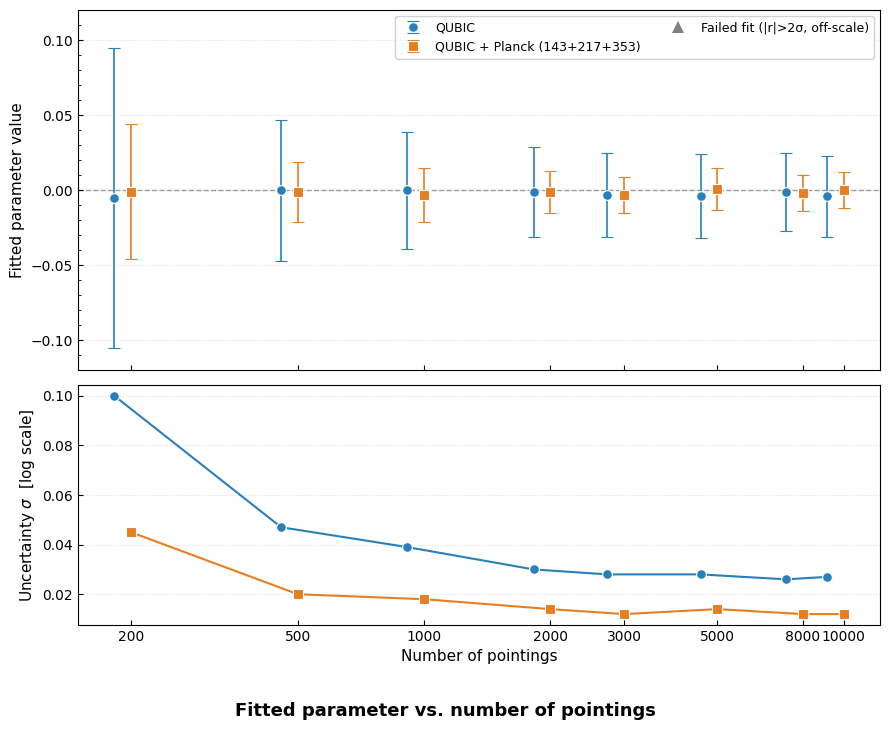

In [3]:
from matplotlib.lines import Line2D

NSIGMA = 2  # consistency threshold: fail if |val| > NSIGMA * err

def is_failed(val, err):
    if err == 0:
        return True           # hit prior boundary
    return abs(val) / err > NSIGMA

configs = list(data.keys())
colors  = ['#2980b9', '#e67e22', '#27ae60']
markers = ['o', 's', '^']
offsets = [-0.04, 0.0, 0.04]

log_npointings = np.log10(npointings)

fig, (ax_val, ax_sig) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 2]})
fig.subplots_adjust(hspace=0.08)

# Value panel: zoom on converged region
YLIM = 0.12

ax_val.axhline(0, color='black', lw=1, ls='--', alpha=0.4, zorder=1)

for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ok   = np.array([not is_failed(v, e) for v, e in data[cfg]])
    x    = log_npointings + off

    if ok.any():
        ax_val.errorbar(x[ok], vals[ok], yerr=errs[ok],
                        fmt=mk, color=col, label=cfg,
                        capsize=4, capthick=1.2, elinewidth=1.2,
                        markersize=7, markeredgewidth=0.8, markeredgecolor='white', zorder=3)

    for j in np.where(~ok)[0]:
        v  = vals[j]
        xi = x[j]
        at_top = v > 0
        y_edge = YLIM * 0.92 if at_top else -YLIM * 0.92
        tri    = '^' if at_top else 'v'
        ax_val.plot(xi, y_edge, marker=tri, color=col, markersize=11,
                    markeredgewidth=0, zorder=4, clip_on=False)
        ax_val.text(xi, y_edge + (0.013 if at_top else -0.013),
                    f'{v:+.3f}', ha='center',
                    va='bottom' if at_top else 'top',
                    fontsize=7.5, color=col, fontweight='bold')

ax_val.set_ylim(-YLIM, YLIM)
ax_val.set_ylabel('Fitted parameter value', fontsize=11)
ax_val.tick_params(direction='in', which='both')
ax_val.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_val.grid(axis='y', which='major', ls=':', alpha=0.4)

handles, labels = ax_val.get_legend_handles_labels()
extra = [
    Line2D([0], [0], marker='^', color='grey', ls='none', markersize=9,
           markeredgewidth=0, label=f'Failed fit (|r|>{NSIGMA}σ, off-scale)'),
]
ax_val.legend(handles + extra, labels + [h.get_label() for h in extra],
              framealpha=0.9, fontsize=9, ncol=2, loc='upper right')

# Sigma panel
for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ok   = np.array([not is_failed(v, e) for v, e in data[cfg]])
    x    = log_npointings + off

    if ok.any():
        ax_sig.plot(x[ok], errs[ok], mk + '-', color=col, markersize=7,
                    markeredgewidth=0.8, markeredgecolor='white', zorder=3)
    if (~ok).any():
        ax_sig.plot(x[~ok], np.where(errs[~ok] > 0, errs[~ok], 1e-4),
                    marker='x', color=col, ls='none',
                    markersize=11, markeredgewidth=2.5, zorder=4)

# ax_sig.set_yscale('log')
ax_sig.set_xticks(log_npointings)
ax_sig.set_xticklabels([str(n) for n in npointings])
ax_sig.set_xlabel('Number of pointings', fontsize=11)
ax_sig.set_ylabel(r'Uncertainty $\sigma$  [log scale]', fontsize=11)
ax_sig.tick_params(direction='in', which='both', axis='both')
ax_sig.grid(axis='y', which='both', ls=':', alpha=0.4)

fig.tight_layout()
fig.suptitle('Fitted parameter vs. number of pointings',
             fontsize=13, fontweight='bold', y=-0.01)
plt.subplots_adjust(bottom=0.1)
plt.savefig('fitted_param_vs_npointings.png', dpi=150, bbox_inches='tight')
plt.show()

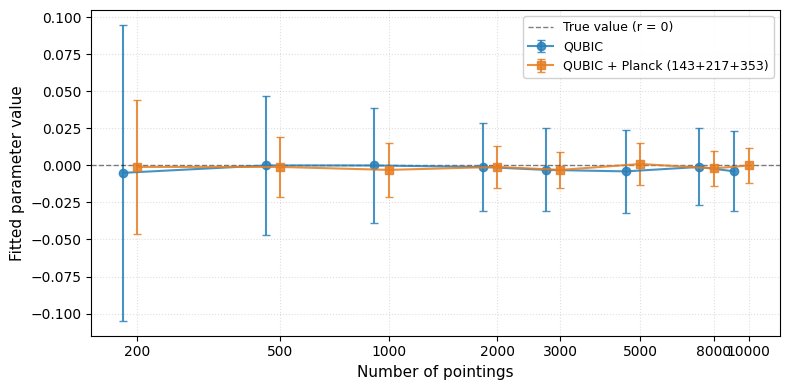

In [4]:
# Simple comparison plot
fig, ax = plt.subplots(figsize=(8, 4))

for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ax.errorbar(log_npointings + off, vals, yerr=errs,
                fmt=mk+'-', color=col, label=cfg,
                capsize=3, markersize=6, alpha=0.85)

ax.axhline(0, color='black', lw=1, ls='--', alpha=0.5, label='True value (r = 0)')
ax.set_xticks(log_npointings)
ax.set_xticklabels([str(n) for n in npointings])
ax.set_xlabel('Number of pointings', fontsize=11)
ax.set_ylabel('Fitted parameter value', fontsize=11)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(ls=':', alpha=0.4)
fig.tight_layout()
plt.show()

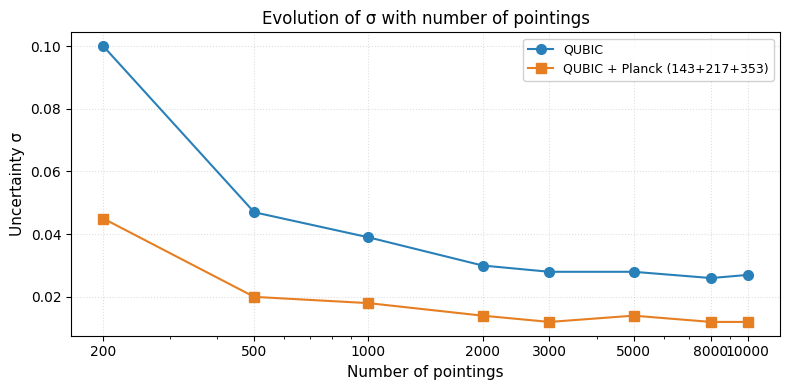

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for cfg, col, mk in zip(configs, colors, markers):
    errs = np.array([e for _, e in data[cfg]])
    ax.plot(npointings, errs, mk+'-', color=col, label=cfg, markersize=7)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xticks(npointings)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(axis='x', style='plain')
ax.set_xlabel('Number of pointings', fontsize=11)
ax.set_ylabel('Uncertainty σ', fontsize=11)
ax.set_title('Evolution of σ with number of pointings', fontsize=12)
ax.grid(ls=':', alpha=0.4)
ax.legend(fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()